# 10 - Machine Learning: Weekly Production Forecast

**Stage 6, model 1 of 4.**

**Factory question this answers:** *"How many units will we actually
produce next week?"* -- not the plan, the realistic expectation, which
is what production planning, raw-material purchasing, and customer
delivery-date commitments should be built on.

### Why this isn't just the production plan
`fact_production_plan_processed` already tells you what was *scheduled*.
This model exists because actual output regularly differs from plan
(unplanned downtime, scrap, changeover overruns) -- the plan is a
starting feature for this model, not the answer. If the model added
nothing over just reading the plan, it wouldn't be worth deploying; the
evaluation section checks exactly that.

### Honesty about the data
This is a simulated dataset covering ~52 weeks with no repeating annual
seasonality (no "this December looked like last December" signal is even
possible with one year of history) and no real external demand
variation -- the plant runs close to a stable capacity plan by
construction. Expect this model to perform *very* well, and don't over-
read that: on real factory data, with real demand volatility and
multi-year seasonality, this is a harder problem than it looks here. The
value of this notebook is the methodology (leak-free time-based
validation, a naive baseline to beat, honest metrics), which transfers
directly to a real deployment even though the absolute accuracy won't.


In [1]:
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '../machine_learning')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import ml_lib as ml

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', 60)

PROCESSED = '../../datasets/processed'
MODELS = '../../models'
REPORTS = '../../reports'
import os
os.makedirs(MODELS, exist_ok=True)

prod = pd.read_csv(f'{PROCESSED}/fact_production_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])
plan = pd.read_csv(f'{PROCESSED}/fact_production_plan_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])


## 10.1 Build the weekly panel

One row per (Process, calendar week). Pooling all four processes into one
panel -- with `Process` as a categorical feature -- gives the model ~4x
more training rows than fitting one model per process, and lets it share
what it learns about general week-to-week patterns across processes.


In [2]:
def week_start(s):
    iso_weekday = s.dt.isocalendar().day
    return s - pd.to_timedelta(iso_weekday - 1, unit='D')

prod['WeekStart'] = week_start(prod['Date'])
plan['WeekStart'] = week_start(plan['Date'])

weekly_actual = prod.groupby(['Process', 'WeekStart']).agg(
    ProducedQty=('ProducedQty', 'sum'),
    Availability=('Availability', 'mean'),
    Performance=('Performance', 'mean'),
    Quality=('Quality', 'mean'),
    OrderCount=('WorkOrder', 'count'),
).reset_index()
weekly_plan = plan.groupby(['Process', 'WeekStart'])['PlannedQty'].sum().reset_index()

panel = weekly_actual.merge(weekly_plan, on=['Process', 'WeekStart'], how='left')
panel = panel.sort_values(['Process', 'WeekStart']).reset_index(drop=True)
panel['ISOWeek'] = panel['WeekStart'].dt.isocalendar().week.astype(int)

print(f"Panel: {len(panel)} rows ({panel['Process'].nunique()} processes x ~{len(panel)//panel['Process'].nunique()} weeks)")
panel.head()


Panel: 212 rows (4 processes x ~53 weeks)


,Process,WeekStart,ProducedQty,Availability,Performance,Quality,OrderCount,PlannedQty,ISOWeek
0,Blow Molding,2025-07-14,166965,0.957753,1.010228,0.976536,28,164495,29
1,Blow Molding,2025-07-21,449421,0.937196,1.030793,0.970403,74,444100,30
2,Blow Molding,2025-07-28,531529,0.945697,1.019536,0.969915,81,525205,31
3,Blow Molding,2025-08-04,450989,0.951441,1.006177,0.964499,75,445915,32
4,Blow Molding,2025-08-11,525254,0.963679,1.004446,0.972508,84,517787,33


## 10.2 Feature engineering: lags and rolling history

A forecast for week *t* may only use information available *before* week
*t* -- `shift(1)` / `shift(2)` on the process's own prior weeks, computed
per process so one process's history never leaks into another's.
`PlannedQty` for week *t* is legitimately known ahead of time (it's the
schedule) and is kept as a feature; it is *not* the target.


In [3]:
panel = panel.sort_values(['Process', 'WeekStart'])
grp = panel.groupby('Process')['ProducedQty']
panel['Lag1_ProducedQty'] = grp.shift(1)
panel['Lag2_ProducedQty'] = grp.shift(2)
panel['RollingMean4_ProducedQty'] = grp.shift(1).rolling(4, min_periods=2).mean().reset_index(level=0, drop=True)
panel['Lag1_Availability'] = panel.groupby('Process')['Availability'].shift(1)

model_df = panel.dropna(subset=['Lag1_ProducedQty', 'Lag2_ProducedQty', 'RollingMean4_ProducedQty']).copy()
model_df = pd.get_dummies(model_df, columns=['Process'], prefix='Process')

feature_cols = [c for c in model_df.columns if c.startswith('Process_')] + [
    'PlannedQty', 'ISOWeek', 'Lag1_ProducedQty', 'Lag2_ProducedQty', 'RollingMean4_ProducedQty', 'Lag1_Availability',
]
target_col = 'ProducedQty'
print(f"Model dataset: {len(model_df)} rows, {len(feature_cols)} features")
model_df[['WeekStart'] + feature_cols + [target_col]].head()


Model dataset: 204 rows, 10 features


,WeekStart,Process_Blow Molding,Process_Hot Foil Stamping,Process_Injection Molding,Process_Screen Printing,PlannedQty,ISOWeek,Lag1_ProducedQty,Lag2_ProducedQty,RollingMean4_ProducedQty,Lag1_Availability,ProducedQty
2,2025-07-28,True,False,False,False,525205,31,449421.0,166965.0,308193.000000,0.937196,531529
3,2025-08-04,True,False,False,False,445915,32,531529.0,449421.0,382638.333333,0.945697,450989
4,2025-08-11,True,False,False,False,517787,33,450989.0,531529.0,399726.000000,0.951441,525254
5,2025-08-18,True,False,False,False,430751,34,525254.0,450989.0,489298.250000,0.963679,436407
6,2025-08-25,True,False,False,False,488678,35,436407.0,525254.0,486044.750000,0.950707,495131


## 10.3 Time-based train/test split and baseline

The naive baseline -- "next week will equal this week's rolling 4-week
average" -- is what the model has to beat to be worth using at all.


In [4]:
train_df, test_df = ml.time_based_split(model_df, 'WeekStart', test_frac=0.2)
X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]
print(f"Train: {len(train_df)} rows ({train_df['WeekStart'].min().date()} to {train_df['WeekStart'].max().date()})")
print(f"Test:  {len(test_df)} rows ({test_df['WeekStart'].min().date()} to {test_df['WeekStart'].max().date()})")

baseline_pred = test_df['RollingMean4_ProducedQty']
print("\nNaive baseline (rolling 4-week average):")
print(ml.regression_metrics(y_test, baseline_pred))


Train: 163 rows (2025-07-28 to 2026-05-04)
Test:  41 rows (2026-05-04 to 2026-07-13)

Naive baseline (rolling 4-week average):
{'MAE': 29812.719512195123, 'RMSE': np.float64(46769.363619847216), 'MAPE_%': np.float64(8.785260666556702), 'R2': 0.9514983182239669}


In [5]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42),
}
results = {}
fitted = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    results[name] = ml.regression_metrics(y_test, pred)
    fitted[name] = m

results['Naive Baseline (rolling 4wk avg)'] = ml.regression_metrics(y_test, baseline_pred)
pd.DataFrame(results).T.round(3)


,MAE,RMSE,MAPE_%,R2
Linear Regression,508.629,690.090,0.173,1.000
Random Forest,7735.324,20947.089,2.756,0.990
XGBoost,6069.410,16692.026,2.398,0.994
Naive Baseline (rolling 4wk avg),29812.720,46769.364,8.785,0.951


## 10.4 Pick the best model, inspect predictions, save it


Best model: Linear Regression


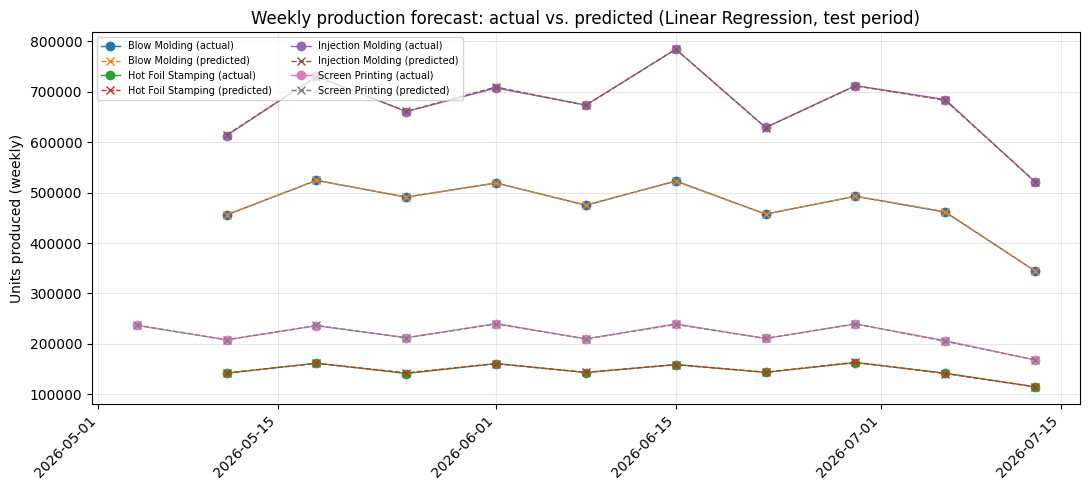

In [6]:
best_name = min(fitted, key=lambda n: ml.regression_metrics(y_test, fitted[n].predict(X_test))['RMSE'])
best_model = fitted[best_name]
print(f"Best model: {best_name}")

test_df = test_df.copy()
test_df['Predicted'] = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(11, 5))
for proc, g in test_df.groupby('Process') if 'Process' in test_df.columns else []:
    pass
for proc_col in [c for c in model_df.columns if c.startswith('Process_')]:
    proc_name = proc_col.replace('Process_', '')
    mask = test_df[proc_col]
    g = test_df[mask].sort_values('WeekStart')
    ax.plot(g['WeekStart'], g['ProducedQty'], marker='o', label=f'{proc_name} (actual)', linewidth=1)
    ax.plot(g['WeekStart'], g['Predicted'], marker='x', linestyle='--', label=f'{proc_name} (predicted)', linewidth=1)
ax.set_ylabel('Units produced (weekly)')
ax.set_title(f'Weekly production forecast: actual vs. predicted ({best_name}, test period)')
ax.legend(fontsize=7, ncol=2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{REPORTS}/35_ml_production_forecast_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
if best_name == 'Random Forest':
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values()
    fig, ax = plt.subplots(figsize=(7, 5))
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Feature importance -- production forecast model')
    plt.tight_layout()
    plt.savefig(f'{REPORTS}/36_ml_production_forecast_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

ml.save_model(best_model, f'{MODELS}/production_forecast_model.pkl',
              feature_cols=feature_cols, target_col=target_col, model_name=best_name,
              trained_on=f"{train_df['WeekStart'].min().date()} to {train_df['WeekStart'].max().date()}",
              test_metrics=ml.regression_metrics(y_test, test_df['Predicted']))
print(f"Saved to {MODELS}/production_forecast_model.pkl")


Saved to ../../models/production_forecast_model.pkl


## 10.5 Next-week forecast (the actual deliverable)

The example output a planner would actually see: predicted production for
the week immediately following the dataset's last known week, per process.


In [8]:
latest = panel.sort_values('WeekStart').groupby('Process').tail(1).copy()
latest_features = pd.get_dummies(latest, columns=['Process'], prefix='Process')
for c in feature_cols:
    if c not in latest_features.columns:
        latest_features[c] = 0
# roll lag features forward by one week using the latest known actuals
latest_features['Lag2_ProducedQty'] = latest_features['Lag1_ProducedQty']
latest_features['Lag1_ProducedQty'] = latest['ProducedQty'].values
latest_features['RollingMean4_ProducedQty'] = latest['RollingMean4_ProducedQty'].values
latest_features['PlannedQty'] = latest['PlannedQty'].values  # assumes next week's plan mirrors current cadence
latest_features['ISOWeek'] = (latest['ISOWeek'] + 1) % 53

next_week_pred = best_model.predict(latest_features[feature_cols])
forecast_table = pd.DataFrame({'Process': latest['Process'].values, 'ForecastedProducedQty': next_week_pred.round(0).astype(int)})
display(forecast_table)
print(f"\nTotal plant-wide forecast for next week: {forecast_table['ForecastedProducedQty'].sum():,} units")


,Process,ForecastedProducedQty
0,Hot Foil Stamping,114491
1,Blow Molding,344444
2,Injection Molding,521558
3,Screen Printing,167945



Total plant-wide forecast for next week: 1,148,438 units


In [9]:
# export for Power BI / MySQL: both the forward forecast and the scored test-set
# (actual vs. predicted) history, so a dashboard can show model performance over time
forecast_table['GeneratedFrom'] = latest['WeekStart'].max().date().isoformat()
forecast_table.to_csv(f'{PROCESSED}/ml_predictions_production_forecast.csv', index=False, encoding='utf-8-sig')

scored_history = test_df[['WeekStart', 'Process' if 'Process' in test_df.columns else feature_cols[0]]].copy() if False else None
scored = test_df.copy()
proc_cols = [c for c in scored.columns if c.startswith('Process_')]
scored['Process'] = scored[proc_cols].idxmax(axis=1).str.replace('Process_', '')
scored[['WeekStart', 'Process', 'ProducedQty', 'Predicted']].rename(
    columns={'ProducedQty': 'ActualProducedQty', 'Predicted': 'PredictedProducedQty'}
).to_csv(f'{PROCESSED}/ml_predictions_production_forecast_history.csv', index=False, encoding='utf-8-sig')
print("Exported ml_predictions_production_forecast.csv and ..._history.csv")


Exported ml_predictions_production_forecast.csv and ..._history.csv
